In [15]:
import numpy as np
import pandas as pd
import glob
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f8f8'

AUDIO_DIR = '../free-spoken-digit-dataset-master/recordings'
SAMPLE_RATE = 48000
N_MFCC = 20
FIXED_LENGTH = 24000
DIGITS = list(range(10))

In [17]:
files = sorted(glob.glob(AUDIO_DIR + '**/*.wav', recursive=True))
print(f"Total files: {len(files)}")
print("\nSample filenames:")
for f in files[:5]:
    print(" ", os.path.basename(f))

# Show class distribution
labels_raw = [int(os.path.basename(f).split('_')[0]) for f in files]
label_counts = pd.Series(labels_raw).value_counts().sort_index()
print(f"\nFiles per digit:\n{label_counts.to_string()}")

Total files: 3000

Sample filenames:
  0_george_0.wav
  0_george_1.wav
  0_george_10.wav
  0_george_11.wav
  0_george_12.wav

Files per digit:
0    300
1    300
2    300
3    300
4    300
5    300
6    300
7    300
8    300
9    300


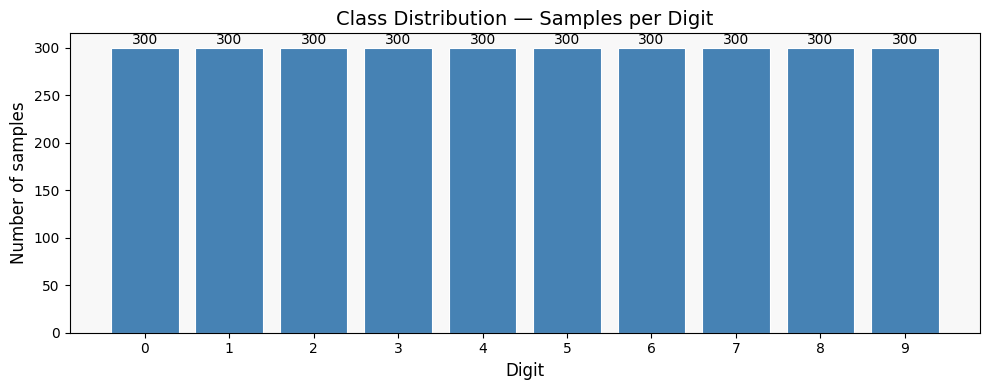

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(label_counts.index, label_counts.values, color='steelblue', edgecolor='white', linewidth=0.8)
ax.set_xticks(DIGITS)
ax.set_xlabel('Digit', fontsize=12)
ax.set_ylabel('Number of samples', fontsize=12)
ax.set_title('Class Distribution — Samples per Digit', fontsize=14)
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

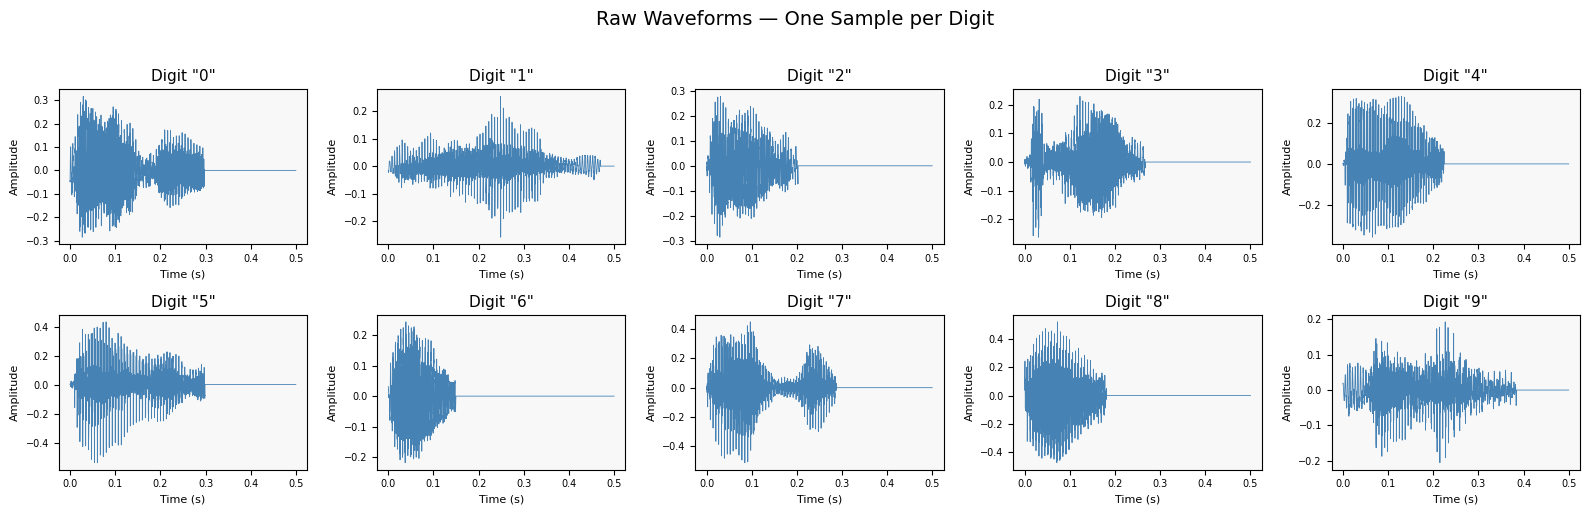

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(16, 5))
axes = axes.flatten()

for digit in DIGITS:
    digit_files = [f for f in files if int(os.path.basename(f).split('_')[0]) == digit]
    audio, sr = librosa.load(digit_files[0], sr=SAMPLE_RATE)
    audio_trimmed, _ = librosa.effects.trim(audio, top_db=10)
    audio_fixed = librosa.util.fix_length(audio_trimmed, size=FIXED_LENGTH)
    
    time = np.linspace(0, len(audio_fixed)/sr, len(audio_fixed))
    axes[digit].plot(time, audio_fixed, color='steelblue', linewidth=0.6)
    axes[digit].set_title(f'Digit "{digit}"', fontsize=11)
    axes[digit].set_xlabel('Time (s)', fontsize=8)
    axes[digit].set_ylabel('Amplitude', fontsize=8)
    axes[digit].tick_params(labelsize=7)

fig.suptitle('Raw Waveforms — One Sample per Digit', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

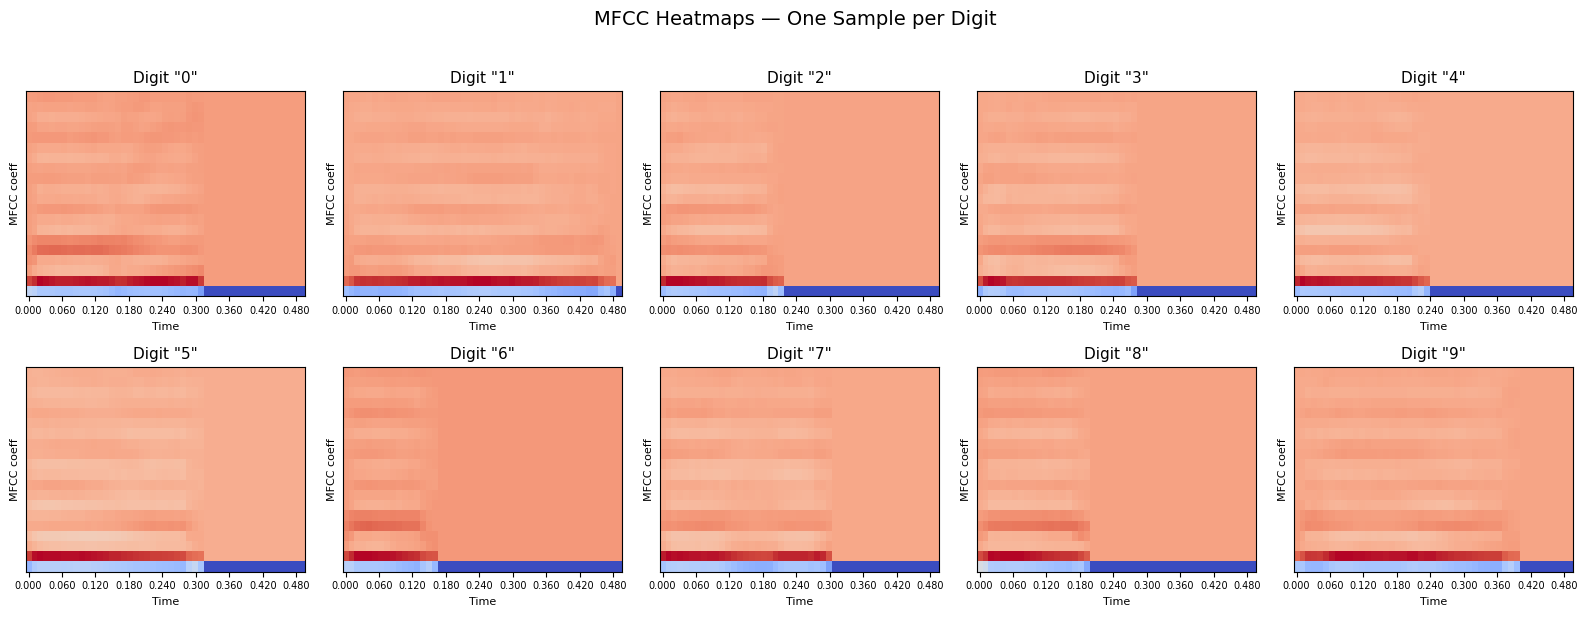

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()

for digit in DIGITS:
    digit_files = [f for f in files if int(os.path.basename(f).split('_')[0]) == digit]
    audio, sr = librosa.load(digit_files[0], sr=SAMPLE_RATE)
    audio_trimmed, _ = librosa.effects.trim(audio, top_db=10)
    audio_fixed = librosa.util.fix_length(audio_trimmed, size=FIXED_LENGTH)
    
    mfcc = librosa.feature.mfcc(y=audio_fixed, sr=sr, n_mfcc=N_MFCC)
    
    img = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=axes[digit], cmap='coolwarm')
    axes[digit].set_title(f'Digit "{digit}"', fontsize=11)
    axes[digit].set_xlabel('Time', fontsize=8)
    axes[digit].set_ylabel('MFCC coeff', fontsize=8)
    axes[digit].tick_params(labelsize=7)

fig.suptitle('MFCC Heatmaps — One Sample per Digit', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

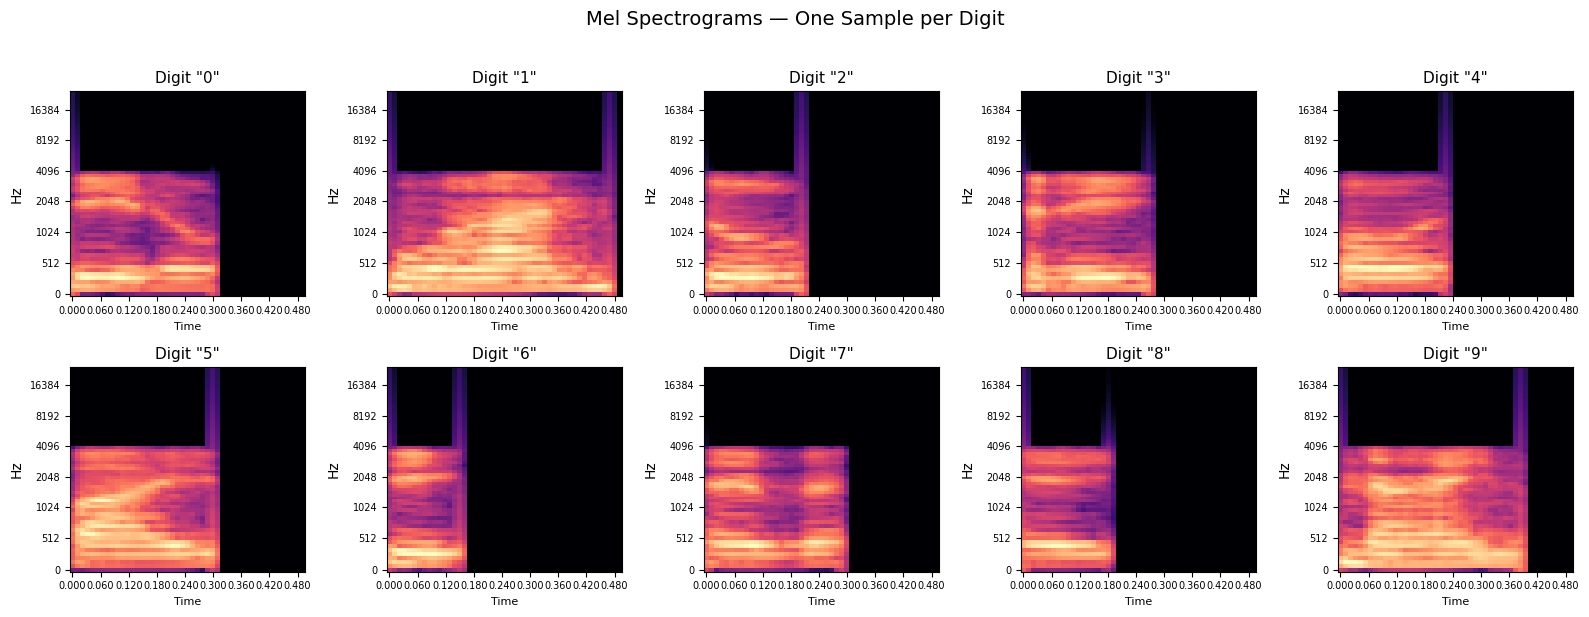

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()

for digit in DIGITS:
    digit_files = [f for f in files if int(os.path.basename(f).split('_')[0]) == digit]
    audio, sr = librosa.load(digit_files[0], sr=SAMPLE_RATE)
    audio_trimmed, _ = librosa.effects.trim(audio, top_db=10)
    audio_fixed = librosa.util.fix_length(audio_trimmed, size=FIXED_LENGTH)
    
    mel = librosa.feature.melspectrogram(y=audio_fixed, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[digit], cmap='magma')
    axes[digit].set_title(f'Digit "{digit}"', fontsize=11)
    axes[digit].set_xlabel('Time', fontsize=8)
    axes[digit].tick_params(labelsize=7)

fig.suptitle('Mel Spectrograms — One Sample per Digit', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [22]:
def make_dataset(files, sample_rate, trim=True):
    dataset = []
    for file in files:
        data, sr = librosa.load(file, sr=sample_rate)
        if trim:
            data, _ = librosa.effects.trim(data, top_db=10)
            data = librosa.util.fix_length(data, size=FIXED_LENGTH)
        mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=N_MFCC)
        label = int(file.split('/')[-1].split('_')[0])
        dataset.append([mfcc, label])
    return dataset

print("Extracting features for all files... (this takes ~1–2 min)")
dataset = make_dataset(files, SAMPLE_RATE)
df = pd.DataFrame(np.array(dataset, dtype=object).squeeze(), columns=['mfcc', 'label'])
print(f"Dataset shape: {df.shape}")
df.head()

Extracting features for all files... (this takes ~1–2 min)
Dataset shape: (3000, 2)


,mfcc,label
0,"[[-296.25897, -311.76355, -353.85654, -353.576...",0
1,"[[-364.91635, -387.62976, -421.8623, -417.8698...",0
2,"[[-353.6358, -370.5368, -390.4735, -381.83594,...",0
3,"[[-389.6008, -396.80573, -398.91425, -392.0702...",0
4,"[[-348.52054, -384.01395, -453.14453, -450.343...",0


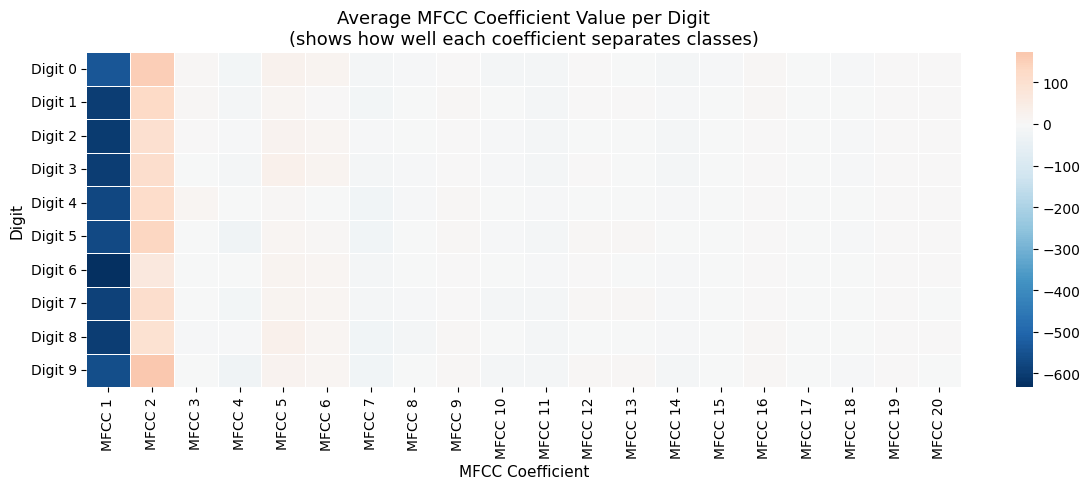

In [23]:
x = np.array(df.mfcc.to_list())   # shape: (N, 20, 47)
y = np.array(df.label.to_list())

mean_mfcc_per_digit = np.array([
    x[y == digit].mean(axis=(0, 2))   # average over samples and time → shape (20,)
    for digit in DIGITS
])  # shape: (10, 20)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    mean_mfcc_per_digit,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    xticklabels=[f'MFCC {i+1}' for i in range(N_MFCC)],
    yticklabels=[f'Digit {d}' for d in DIGITS],
    linewidths=0.4,
    linecolor='white'
)
ax.set_title('Average MFCC Coefficient Value per Digit\n(shows how well each coefficient separates classes)', fontsize=13)
ax.set_xlabel('MFCC Coefficient', fontsize=11)
ax.set_ylabel('Digit', fontsize=11)
plt.tight_layout()
plt.show()

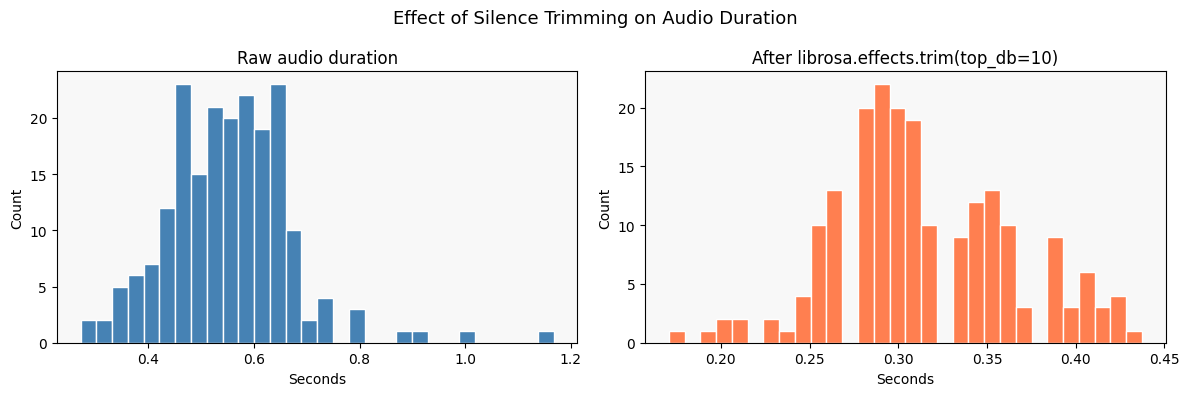

Raw    — mean: 0.553s  std: 0.119s
Trimmed — mean: 0.313s  std: 0.050s


In [24]:
durations_raw, durations_trimmed = [], []

for f in files[:200]:   # sample 200 files to keep it fast
    audio, sr = librosa.load(f, sr=SAMPLE_RATE)
    durations_raw.append(len(audio) / sr)
    trimmed, _ = librosa.effects.trim(audio, top_db=10)
    durations_trimmed.append(len(trimmed) / sr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(durations_raw, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Raw audio duration', fontsize=12)
axes[0].set_xlabel('Seconds')
axes[0].set_ylabel('Count')

axes[1].hist(durations_trimmed, bins=30, color='coral', edgecolor='white')
axes[1].set_title('After librosa.effects.trim(top_db=10)', fontsize=12)
axes[1].set_xlabel('Seconds')
axes[1].set_ylabel('Count')

fig.suptitle('Effect of Silence Trimming on Audio Duration', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Raw    — mean: {np.mean(durations_raw):.3f}s  std: {np.std(durations_raw):.3f}s")
print(f"Trimmed — mean: {np.mean(durations_trimmed):.3f}s  std: {np.std(durations_trimmed):.3f}s")